In [1]:
# setup/repo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import linregress
from scipy.stats import truncnorm
import os
!rm -rf PGST
!git clone --quiet https://github.com/mickdeines/PGST/
os.chdir("PGST")

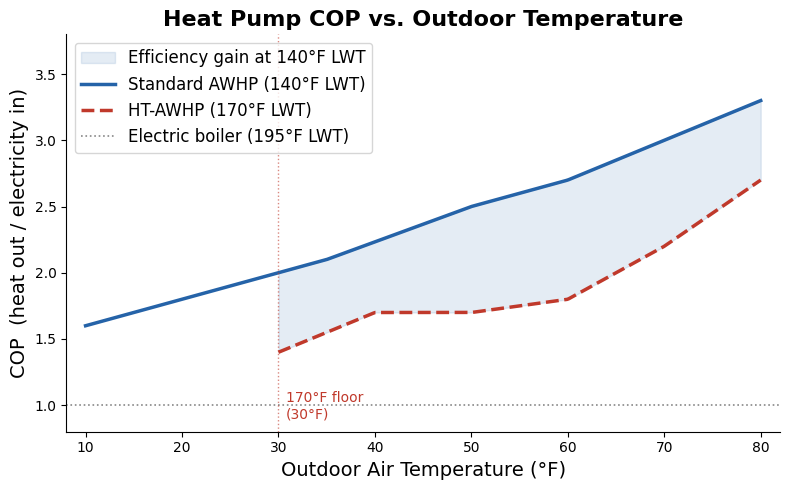

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ── Nyle spec data ────────────────────────────────────────────────────────────
NYLE_140 = {
    80: (290_900, 3.3), 70: (256_450, 3.0), 60: (222_000, 2.7),
    50: (187_920, 2.5), 35: (136_800, 2.1), 20: (101_160, 1.8),
    10: ( 77_400, 1.6),
}
NYLE_170 = {
    80: (243_300, 2.7), 70: (212_850, 2.2), 60: (182_400, 1.8),
    50: (153_550, 1.7), 40: (124_700, 1.7), 30: ( 92_000, 1.4),
}

NYLE_140_MIN = 10
NYLE_170_MIN = 30

def make_cop_fn(spec):
    t = sorted(spec.keys())
    cops = [spec[x][1] for x in t]
    return interp1d(t, cops, kind='linear',
                    fill_value=(cops[0], cops[-1]), bounds_error=False)

cop_fn_140 = make_cop_fn(NYLE_140)
cop_fn_170 = make_cop_fn(NYLE_170)

# ── COP curves ────────────────────────────────────────────────────────────────
oat_range     = np.linspace(NYLE_140_MIN, 80, 300)
oat_range_170 = np.linspace(NYLE_170_MIN, 80, 300)
cop_140_curve = [float(cop_fn_140(t)) for t in oat_range]
cop_170_curve = [float(cop_fn_170(t)) for t in oat_range_170]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.fill_between(oat_range_170, cop_170_curve,
                [float(cop_fn_140(t)) for t in oat_range_170],
                alpha=0.12, color="#2563a8", label="Efficiency gain at 140°F LWT")
ax.plot(oat_range,     cop_140_curve, color="#2563a8", linewidth=2.5,
        label="Standard AWHP (140°F LWT)")
ax.plot(oat_range_170, cop_170_curve, color="#c0392b", linewidth=2.5,
        linestyle="--", label="HT-AWHP (170°F LWT)")
ax.axhline(1.0, color="#888888", linewidth=1.2, linestyle=":",
           label="Electric boiler (195°F LWT)")

ax.axvline(NYLE_170_MIN, color="#c0392b", linewidth=1, linestyle=":", alpha=0.6)
ax.text(NYLE_170_MIN + 0.8, 0.88, f"170°F floor\n({NYLE_170_MIN}°F)",
        fontsize=10, color="#c0392b", va="bottom")

ax.set_xlabel("Outdoor Air Temperature (°F)", fontsize=14)
ax.set_ylabel("COP  (heat out / electricity in)", fontsize=14)
ax.set_title("Heat Pump COP vs. Outdoor Temperature", fontsize=16, fontweight="bold")
ax.set_xlim(8, 82)
ax.set_ylim(0.8, 3.8)
ax.legend(fontsize=12, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [3]:
# Longhouse envelope
LH_ROOF  = 6_000   # sqft
LH_WALL1 = 2000    #Placeholder
LH_WALL2 = 2000
LH_WALL3 =   1000
LH_WALL4 =   1000

# Ed Center envelope
EC_ROOF  = 4_060
EC_WALL1 = 1_500
EC_WALL2 = 1_500
EC_WALL3 =   900
EC_WALL4 =   900

LH_ENVELOPE = LH_ROOF + LH_WALL1 + LH_WALL2 + LH_WALL3 + LH_WALL4
EC_ENVELOPE = EC_ROOF + EC_WALL1 + EC_WALL2 + EC_WALL3 + EC_WALL4

LH_FRAC = LH_ENVELOPE / (LH_ENVELOPE + EC_ENVELOPE)
EC_FRAC = 1 - LH_FRAC
LH_FRAC = SQFT_LONGHOUSE / (SQFT_LONGHOUSE + SQFT_ED_CENTER)
EC_FRAC = 1 - LH_FRAC

NameError: name 'SQFT_LONGHOUSE' is not defined

In [ ]:
# ── CELL: Option Comparison — CAPEX, OPEX, Savings, Payback ──────────────────
# Requires: df (with oat_f, load_btu, datetime columns), NYLE_140, NYLE_170,
#           interp1d, np, pd, plt already imported

# ══════════════════════════════════════════════════════════════════════════════
# INPUTS
# ══════════════════════════════════════════════════════════════════════════════

# PSE Schedule 25 — energy + PCA surcharge ($/kWh)
ELEC_PRICE_WINTER = 0.1281   # Oct–Mar  ($128.1/MWh)
ELEC_PRICE_SUMMER = 0.1191   # Apr–Sep  ($119.1/MWh)
WINTER_MONTHS     = [10, 11, 12, 1, 2, 3]

PROPANE_PRICE  = 2.50    # $/gal
PROPANE_HHV    = 91_500  # BTU/gal

BOILER_INPUT_BTU  = 378_000
BOILER_EFF        = 0.831
BOILER_OUTPUT_BTU = BOILER_INPUT_BTU * BOILER_EFF

# CAPEX ($) — update with real quotes
CAPEX_A1 = 140_000   # Full HP 140°F LWT
CAPEX_A2 = 140_000   # Full HP 170°F LWT
CAPEX_B  = 120_000   # Hybrid: HP (LH 140°F) + electric boiler (EC)
CAPEX_C  =  80_000   # Full electric boiler
CAPEX_D  =  50_000   # Full propane boiler replacement (baseline)

NYLE_140_MIN = 10    # °F
NYLE_170_MIN = 30    # °F

# ══════════════════════════════════════════════════════════════════════════════
# SETUP
# ══════════════════════════════════════════════════════════════════════════════

from scipy.interpolate import interp1d
import numpy as np

def make_cop_fn(spec_dict):
    t = sorted(spec_dict.keys())
    v = [spec_dict[x][1] for x in t]
    return interp1d(t, v, kind='linear',
                    fill_value=(v[0], v[-1]), bounds_error=False)

cop_fn_140 = make_cop_fn(NYLE_140)
cop_fn_170 = make_cop_fn(NYLE_170)

# Add season flag — align weather months to df by row order
wx = pd.read_csv("ERA5 Hourly Temperatures 2015-2026.csv")
wx['time_pacific'] = pd.to_datetime(wx['time_pacific'], utc=True)
wx24 = wx[wx['time_pacific'].dt.year == 2024].reset_index(drop=True)
df['is_winter'] = wx24['time_pacific'].dt.month.isin(WINTER_MONTHS).values[:len(df)]

def elec_cost(kwh_win, kwh_sum):
    return kwh_win * ELEC_PRICE_WINTER + kwh_sum * ELEC_PRICE_SUMMER

def prop_cost(gal):
    return gal * PROPANE_PRICE

# ══════════════════════════════════════════════════════════════════════════════
# OPTION A1: Full HP at 140°F LWT — high efficiency
# ══════════════════════════════════════════════════════════════════════════════

kwh_A1_win = kwh_A1_sum = 0.0
for _, row in df.iterrows():
    oat = row['oat_f']
    btu = row['load_btu']
    if oat < NYLE_140_MIN or btu <= 0:
        continue
    kwh = (btu / 3412.14) / float(cop_fn_140(oat))
    if row['is_winter']:
        kwh_A1_win += kwh
    else:
        kwh_A1_sum += kwh

prop_gal_A1 = 0.0
opex_A1 = elec_cost(kwh_A1_win, kwh_A1_sum) + prop_cost(prop_gal_A1)

# ══════════════════════════════════════════════════════════════════════════════
# OPTION A2: Full HP at 170°F LWT — lower efficiency
# Propane boiler covers hours below 30°F
# ══════════════════════════════════════════════════════════════════════════════

kwh_A2_win = kwh_A2_sum = 0.0
backup_btu_A2_win = backup_btu_A2_sum = 0.0
for _, row in df.iterrows():
    oat = row['oat_f']
    btu = row['load_btu']
    if btu <= 0:
        continue
    if oat >= NYLE_170_MIN:
        kwh = (btu / 3412.14) / float(cop_fn_170(oat))
        if row['is_winter']:
            kwh_A2_win += kwh
        else:
            kwh_A2_sum += kwh
    else:
        if row['is_winter']:
            backup_btu_A2_win += btu
        else:
            backup_btu_A2_sum += btu

prop_gal_A2 = ((backup_btu_A2_win + backup_btu_A2_sum) / BOILER_EFF) / PROPANE_HHV
opex_A2 = elec_cost(kwh_A2_win, kwh_A2_sum) + prop_cost(prop_gal_A2)

# ══════════════════════════════════════════════════════════════════════════════
# OPTION B: Hybrid — HP (LH 140°F) + Electric boiler (EC)
# ══════════════════════════════════════════════════════════════════════════════

kwh_B_win = kwh_B_sum = 0.0
for _, row in df.iterrows():
    oat = row['oat_f']
    btu = row['load_btu']
    if btu <= 0:
        continue
    lh_btu = btu * LH_FRAC
    ec_btu = btu * EC_FRAC
    # Longhouse — heat pump at 140°F
    if oat >= NYLE_140_MIN:
        kwh_hp = (lh_btu / 3412.14) / float(cop_fn_140(oat))
    else:
        kwh_hp = 0.0
    # Ed Center — electric boiler COP=1
    kwh_eb = ec_btu / 3412.14
    kwh = kwh_hp + kwh_eb
    if row['is_winter']:
        kwh_B_win += kwh
    else:
        kwh_B_sum += kwh

prop_gal_B = 0.0
opex_B = elec_cost(kwh_B_win, kwh_B_sum) + prop_cost(prop_gal_B)

# ══════════════════════════════════════════════════════════════════════════════
# OPTION C: Full electric boiler (COP = 1)
# ══════════════════════════════════════════════════════════════════════════════

kwh_C_win = df.loc[df['is_winter'],  'load_btu'].sum() / 3412.14
kwh_C_sum = df.loc[~df['is_winter'], 'load_btu'].sum() / 3412.14
prop_gal_C = 0.0
opex_C = elec_cost(kwh_C_win, kwh_C_sum) + prop_cost(prop_gal_C)

# ══════════════════════════════════════════════════════════════════════════════
# OPTION D: Full propane boiler — BASELINE
# ══════════════════════════════════════════════════════════════════════════════

prop_gal_D = (df['load_btu'].sum() / BOILER_EFF) / PROPANE_HHV
kwh_D_win  = kwh_D_sum = 0.0
opex_D = prop_cost(prop_gal_D)

# ══════════════════════════════════════════════════════════════════════════════
# SAVINGS & PAYBACK
# ══════════════════════════════════════════════════════════════════════════════

def savings_vs_D(opex):
    return opex_D - opex

def payback(capex, sav):
    incremental = capex - CAPEX_D
    if sav <= 0:
        return float('inf')
    return incremental / sav

def pb_str(capex, sav):
    pb = payback(capex, sav)
    if np.isinf(pb):   return '∞'
    if pb < 0:         return 'Immediate'
    return f'{pb:.1f} yr'

# ══════════════════════════════════════════════════════════════════════════════
# CONSOLE SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*80}")
print(f"  OPTION COMPARISON  |  Propane ${PROPANE_PRICE}/gal  |  "
      f"Elec ${ELEC_PRICE_WINTER}/kWh (win) / ${ELEC_PRICE_SUMMER}/kWh (sum)")
print(f"{'='*80}")
print(f"  {'Opt':<4} {'Description':<26} {'CAPEX':>9}  "
      f"{'kWh Win':>9}  {'kWh Sum':>9}  {'Prop gal':>9}  "
      f"{'OPEX/yr':>9}  {'Savings':>9}  {'Payback':>9}")
print(f"  {'-'*102}")

rows_data = [
    ('A1','Full HP 140°F LWT',   CAPEX_A1, kwh_A1_win, kwh_A1_sum, prop_gal_A1, opex_A1),
    ('A2','Full HP 170°F LWT',   CAPEX_A2, kwh_A2_win, kwh_A2_sum, prop_gal_A2, opex_A2),
    ('B', 'Hybrid HP+Elec boiler',CAPEX_B, kwh_B_win,  kwh_B_sum,  prop_gal_B,  opex_B),
    ('C', 'Full electric boiler', CAPEX_C, kwh_C_win,  kwh_C_sum,  prop_gal_C,  opex_C),
    ('D', 'Propane boiler (base)',CAPEX_D,  kwh_D_win,  kwh_D_sum,  prop_gal_D,  opex_D),
]
for key, desc, capex, kw, ks, pg, opex in rows_data:
    sav = savings_vs_D(opex)
    pb  = pb_str(capex, sav) if key != 'D' else '—'
    print(f"  {key:<4} {desc:<26} ${capex:>8,.0f}  "
          f"{kw:>9,.0f}  {ks:>9,.0f}  {pg:>9,.0f}  "
          f"${opex:>8,.0f}  ${sav:>8,.0f}  {pb:>9}")

# ══════════════════════════════════════════════════════════════════════════════
# TABLE PLOT
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

OPT_COLORS = ['#2563a8','#1a7a4a','#7b3fa0','#b45309','#555555']
LABEL_BG   = '#e8edf2'; HDR_BG = '#1a3a5c'
ROW_ALT    = '#f0f4f8'; ROW_NORM = 'white'
TEXT_DARK  = '#1a1a1a'; MUTED_C  = '#666666'

opt_names  = ['Option A1','Option A2','Option B','Option C','Option D']
n_cols     = 6

table_rows = [
    ['Description',
     'Full HP\n140°F LWT\n(high eff.)',
     'Full HP\n170°F LWT\n(lower eff.)',
     'Hybrid\nHP (LH 140°F)\n+ Elec boiler (EC)',
     'Full Electric\nBoiler\n(COP = 1)',
     'Full Propane\nBoiler\n(baseline)'],
    ['Heat source — Longhouse', 'HP 140°F',    'HP 170°F',    'HP 140°F',    'Elec boiler', 'Propane'],
    ['Heat source — Ed Center', 'HP 140°F',    'HP 170°F',    'Elec boiler', 'Elec boiler', 'Propane'],
    ['CAPEX',
     f'${CAPEX_A1:,.0f}', f'${CAPEX_A2:,.0f}',
     f'${CAPEX_B:,.0f}',  f'${CAPEX_C:,.0f}',  f'${CAPEX_D:,.0f}'],
    ['Elec — Winter kWh (Oct–Mar)',
     f'{kwh_A1_win:,.0f}', f'{kwh_A2_win:,.0f}',
     f'{kwh_B_win:,.0f}',  f'{kwh_C_win:,.0f}',  '—'],
    ['Elec — Summer kWh (Apr–Sep)',
     f'{kwh_A1_sum:,.0f}', f'{kwh_A2_sum:,.0f}',
     f'{kwh_B_sum:,.0f}',  f'{kwh_C_sum:,.0f}',  '—'],
    [f'Elec cost (${ELEC_PRICE_WINTER}/kWh win\n${ELEC_PRICE_SUMMER}/kWh sum)',
     f'${elec_cost(kwh_A1_win,kwh_A1_sum):,.0f}/yr',
     f'${elec_cost(kwh_A2_win,kwh_A2_sum):,.0f}/yr',
     f'${elec_cost(kwh_B_win,kwh_B_sum):,.0f}/yr',
     f'${elec_cost(kwh_C_win,kwh_C_sum):,.0f}/yr',
     '—'],
    [f'Propane (gal/yr)',
     '0', f'{prop_gal_A2:,.0f}', '0', '0', f'{prop_gal_D:,.0f}'],
    [f'Propane cost (${PROPANE_PRICE}/gal)',
     '$0', f'${prop_cost(prop_gal_A2):,.0f}/yr',
     '$0', '$0', f'${prop_cost(prop_gal_D):,.0f}/yr'],
    ['Total annual OPEX',
     f'${opex_A1:,.0f}/yr', f'${opex_A2:,.0f}/yr',
     f'${opex_B:,.0f}/yr',  f'${opex_C:,.0f}/yr',  f'${opex_D:,.0f}/yr'],
    ['Annual savings vs Option D',
     f'${savings_vs_D(opex_A1):,.0f}',
     f'${savings_vs_D(opex_A2):,.0f}',
     f'${savings_vs_D(opex_B):,.0f}',
     f'${savings_vs_D(opex_C):,.0f}', '—'],
    ['Incremental CAPEX vs D',
     f'${CAPEX_A1-CAPEX_D:,.0f}', f'${CAPEX_A2-CAPEX_D:,.0f}',
     f'${CAPEX_B-CAPEX_D:,.0f}',  f'${CAPEX_C-CAPEX_D:,.0f}',  '$0'],
    ['Simple payback vs D',
     pb_str(CAPEX_A1, savings_vs_D(opex_A1)),
     pb_str(CAPEX_A2, savings_vs_D(opex_A2)),
     pb_str(CAPEX_B,  savings_vs_D(opex_B)),
     pb_str(CAPEX_C,  savings_vs_D(opex_C)), '—'],
    ['Propane displaced',
     '100%',
     f'{(prop_gal_D-prop_gal_A2)/prop_gal_D:.0%}',
     '100%', '100%', '0%'],
]

col_widths = [0.18] + [0.153] * 5
x_starts   = [0.005]
for w in col_widths[:-1]:
    x_starts.append(x_starts[-1] + w + 0.002)

fig, ax = plt.subplots(figsize=(20, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.axis('off')

row_height = 0.057
y_start    = 0.96

# Header
for c_idx in range(n_cols):
    x = x_starts[c_idx]; w = col_widths[c_idx]
    bg    = HDR_BG if c_idx == 0 else OPT_COLORS[c_idx - 1]
    label = '' if c_idx == 0 else opt_names[c_idx - 1]
    rect  = plt.Rectangle((x, y_start - row_height), w, row_height,
                           transform=ax.transAxes, facecolor=bg,
                           edgecolor='#cccccc', linewidth=0.5, clip_on=False)
    ax.add_patch(rect)
    ax.text(x + w/2, y_start - row_height/2, label,
            transform=ax.transAxes, fontsize=9.5, color='white',
            fontweight='bold', va='center', ha='center')

for r_idx, row in enumerate(table_rows):
    rh = row_height * 2.1 if r_idx == 0 else (row_height * 1.6 if '\n' in row[0] else row_height)
    y  = y_start - (r_idx + 1) * row_height

    for c_idx, cell in enumerate(row):
        x = x_starts[c_idx]; w = col_widths[c_idx]
        try:
            val    = float(str(cell).replace('$','').replace(',','')
                           .replace('/yr','').replace('%','').replace(' yr',''))
            is_neg = val < 0
        except:
            is_neg = False

        if c_idx == 0:
            bg = LABEL_BG; fg = TEXT_DARK; fw = 'bold'
            fs = 7.5; ha = 'left'; xoff = x + 0.008
        else:
            bg = ROW_ALT if r_idx % 2 == 0 else ROW_NORM
            fg = '#c0392b' if is_neg else TEXT_DARK
            fw = 'normal'; fs = 7.5; ha = 'center'; xoff = x + w/2

        rect = plt.Rectangle((x, y - rh), w, rh,
                              transform=ax.transAxes, facecolor=bg,
                              edgecolor='#cccccc', linewidth=0.5, clip_on=False)
        ax.add_patch(rect)
        ax.text(xoff, y - rh/2, cell,
                transform=ax.transAxes, fontsize=fs, color=fg, fontweight=fw,
                va='center', ha=ha,
                multialignment='center' if ha == 'center' else 'left')

ax.set_xlim(0, 1); ax.set_ylim(-0.1, 1)
ax.text(0.5, y_start + 0.04,
        "Heating System Option Comparison — Port Gamble S'Klallam Tribe",
        transform=ax.transAxes, fontsize=13, fontweight='bold',
        color=TEXT_DARK, ha='center')
ax.text(0.5, y_start + 0.005,
        f"PSE Schedule 25  ·  Elec: ${ELEC_PRICE_WINTER}/kWh winter / ${ELEC_PRICE_SUMMER}/kWh summer  ·  "
        f"Propane: ${PROPANE_PRICE}/gal  ·  "
        f"LH {SQFT_LONGHOUSE:,} sqft / EC {SQFT_ED_CENTER:,} sqft  ·  "
        f"Payback = incremental CAPEX vs D / annual savings vs D",
        transform=ax.transAxes, fontsize=7.5, color=MUTED_C, ha='center')

plt.tight_layout()
plt.savefig('option_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Saved: option_comparison.png')

In [ ]:
# ── CELL: Option Comparison — Two Tables ──────────────────────────────────────
# Requires: df (with oat_f, load_btu, is_winter), NYLE_140, NYLE_170,
#           cop_fn_140, cop_fn_170, all cost variables already calculated

# ══════════════════════════════════════════════════════════════════════════════
# INPUTS
# ══════════════════════════════════════════════════════════════════════════════

SQFT_LONGHOUSE = 6_000
SQFT_ED_CENTER = 4_060
LH_FRAC = SQFT_LONGHOUSE / (SQFT_LONGHOUSE + SQFT_ED_CENTER)
EC_FRAC = 1 - LH_FRAC

ELEC_PRICE_WINTER = 0.1281
ELEC_PRICE_SUMMER = 0.1191
WINTER_MONTHS     = [10, 11, 12, 1, 2, 3]

PROPANE_PRICE = 2.50
PROPANE_HHV   = 91_500

BOILER_EFF        = 0.831
NYLE_140_MIN      = 10
NYLE_170_MIN      = 30

CAPEX_A1 = 140_000
CAPEX_A2 = 140_000
CAPEX_B  = 120_000
CAPEX_C  =  80_000
CAPEX_D  =  50_000

# ══════════════════════════════════════════════════════════════════════════════
# CALCULATIONS
# ══════════════════════════════════════════════════════════════════════════════

from scipy.interpolate import interp1d
import numpy as np

def make_cop_fn(spec_dict):
    t = sorted(spec_dict.keys())
    v = [spec_dict[x][1] for x in t]
    return interp1d(t, v, kind='linear',
                    fill_value=(v[0], v[-1]), bounds_error=False)

cop_fn_140 = make_cop_fn(NYLE_140)
cop_fn_170 = make_cop_fn(NYLE_170)

wx = pd.read_csv("ERA5 Hourly Temperatures 2015-2026.csv")
wx['time_pacific'] = pd.to_datetime(wx['time_pacific'], utc=True)
wx24 = wx[wx['time_pacific'].dt.year == 2024].reset_index(drop=True)
df['is_winter'] = wx24['time_pacific'].dt.month.isin(WINTER_MONTHS).values[:len(df)]

def elec_cost(kwh_win, kwh_sum):
    return kwh_win * ELEC_PRICE_WINTER + kwh_sum * ELEC_PRICE_SUMMER

def prop_cost(gal):
    return gal * PROPANE_PRICE

# ── Option A1 ─────────────────────────────────────────────────────────────────
kwh_A1_win = kwh_A1_sum = 0.0
for _, row in df.iterrows():
    oat = row['oat_f']; btu = row['load_btu']
    if oat < NYLE_140_MIN or btu <= 0: continue
    kwh = (btu / 3412.14) / float(cop_fn_140(oat))
    if row['is_winter']: kwh_A1_win += kwh
    else:                kwh_A1_sum += kwh
opex_A1 = elec_cost(kwh_A1_win, kwh_A1_sum)
ecost_A1 = opex_A1

# ── Option A2 ─────────────────────────────────────────────────────────────────
kwh_A2_win = kwh_A2_sum = backup_A2 = 0.0
for _, row in df.iterrows():
    oat = row['oat_f']; btu = row['load_btu']
    if btu <= 0: continue
    if oat >= NYLE_170_MIN:
        kwh = (btu / 3412.14) / float(cop_fn_170(oat))
        if row['is_winter']: kwh_A2_win += kwh
        else:                kwh_A2_sum += kwh
    else:
        backup_A2 += btu
prop_gal_A2  = (backup_A2 / BOILER_EFF) / PROPANE_HHV
ecost_A2     = elec_cost(kwh_A2_win, kwh_A2_sum)
pcost_A2     = prop_cost(prop_gal_A2)
opex_A2      = ecost_A2 + pcost_A2

# ── Option B ──────────────────────────────────────────────────────────────────
kwh_B_win = kwh_B_sum = 0.0
for _, row in df.iterrows():
    oat = row['oat_f']; btu = row['load_btu']
    if btu <= 0: continue
    kwh_hp = ((btu * LH_FRAC / 3412.14) / float(cop_fn_140(oat))
               if oat >= NYLE_140_MIN else 0.0)
    kwh_eb = btu * EC_FRAC / 3412.14
    kwh = kwh_hp + kwh_eb
    if row['is_winter']: kwh_B_win += kwh
    else:                kwh_B_sum += kwh
opex_B = elec_cost(kwh_B_win, kwh_B_sum)
ecost_B = opex_B

# ── Option C ──────────────────────────────────────────────────────────────────
kwh_C_win = df.loc[df['is_winter'],  'load_btu'].sum() / 3412.14
kwh_C_sum = df.loc[~df['is_winter'], 'load_btu'].sum() / 3412.14
opex_C  = elec_cost(kwh_C_win, kwh_C_sum)
ecost_C = opex_C

# ── Option D ──────────────────────────────────────────────────────────────────
prop_gal_D = (df['load_btu'].sum() / BOILER_EFF) / PROPANE_HHV
opex_D     = prop_cost(prop_gal_D)
pcost_D    = opex_D

def sav(opex): return opex_D - opex

def pb_str(capex, opex):
    s = sav(opex)
    inc = capex - CAPEX_D
    if inc <= 0:     return 'Immediate'
    if s <= 0:       return '∞'
    return f'{inc/s:.1f} yr'

# ══════════════════════════════════════════════════════════════════════════════
# PLOT HELPERS
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

OPT_COLORS = ['#2563a8','#1a7a4a','#7b3fa0','#b45309','#555555']
LABEL_BG   = '#e8edf2'; HDR_BG = '#1a3a5c'
ROW_ALT    = '#f0f4f8'; ROW_NORM = 'white'
TEXT_DARK  = '#1a1a1a'; MUTED_C  = '#666666'
OPT_NAMES  = ['Option A1','Option A2','Option B','Option C','Option D']

def draw_table(ax, table_rows, col_widths, row_height, y_start, header_labels):
    n_cols = len(header_labels)
    x_starts = [0.005]
    for w in col_widths[:-1]:
        x_starts.append(x_starts[-1] + w + 0.002)

    # Header
    for c_idx, label in enumerate(header_labels):
        x = x_starts[c_idx]; w = col_widths[c_idx]
        bg = HDR_BG if c_idx == 0 else OPT_COLORS[c_idx - 1]
        rect = plt.Rectangle((x, y_start - row_height), w, row_height,
                              transform=ax.transAxes, facecolor=bg,
                              edgecolor='#cccccc', linewidth=0.5, clip_on=False)
        ax.add_patch(rect)
        ax.text(x + w/2, y_start - row_height/2, label,
                transform=ax.transAxes, fontsize=9.5, color='white',
                fontweight='bold', va='center', ha='center')

    # Rows
    for r_idx, row in enumerate(table_rows):
        rh = row_height * 2.0 if r_idx == 0 else row_height
        y  = y_start - (r_idx + 1) * row_height
        for c_idx, cell in enumerate(row):
            x = x_starts[c_idx]; w = col_widths[c_idx]
            try:
                val    = float(str(cell).replace('$','').replace(',','')
                               .replace('/yr','').replace('%','').replace(' yr',''))
                is_neg = val < 0
            except:
                is_neg = False
            if c_idx == 0:
                bg = LABEL_BG; fg = TEXT_DARK; fw = 'bold'
                fs = 8; ha = 'left'; xoff = x + 0.010
            else:
                bg = ROW_ALT if r_idx % 2 == 0 else ROW_NORM
                fg = '#c0392b' if is_neg else TEXT_DARK
                fw = 'normal'; fs = 8; ha = 'center'; xoff = x + w/2
            rect = plt.Rectangle((x, y - rh), w, rh,
                                  transform=ax.transAxes, facecolor=bg,
                                  edgecolor='#cccccc', linewidth=0.5, clip_on=False)
            ax.add_patch(rect)
            ax.text(xoff, y - rh/2, str(cell),
                    transform=ax.transAxes, fontsize=fs, color=fg,
                    fontweight=fw, va='center', ha=ha,
                    multialignment='center' if ha == 'center' else 'left')

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 1: System description
# ══════════════════════════════════════════════════════════════════════════════

t1_rows = [
    ['Description',
     'Full heat pump\nreplacement\n(high efficiency)',
     'Full heat pump\nreplacement\n(lower efficiency)',
     'Hybrid — HP\n(Longhouse) +\nElec boiler (EC)',
     'Full electric\nboiler\nreplacement',
     'Full propane\nboiler\nreplacement'],
    ['Heat source — Longhouse',
     'HP 140°F LWT', 'HP 170°F LWT', 'HP 140°F LWT', 'Electric boiler', 'Propane boiler'],
    ['Heat source — Ed Center',
     'HP 140°F LWT', 'HP 170°F LWT', 'Electric boiler','Electric boiler','Propane boiler'],
    ['CAPEX',
     f'${CAPEX_A1:,.0f}', f'${CAPEX_A2:,.0f}',
     f'${CAPEX_B:,.0f}',  f'${CAPEX_C:,.0f}', f'${CAPEX_D:,.0f}'],
    ['Energy cost\n(elec A–C / propane D)',
     f'${ecost_A1:,.0f}/yr',
     f'${ecost_A2:,.0f}/yr\n+ ${pcost_A2:,.0f} propane',
     f'${ecost_B:,.0f}/yr',
     f'${ecost_C:,.0f}/yr',
     f'${pcost_D:,.0f}/yr'],
]

fig1, ax1 = plt.subplots(figsize=(20, 5.5))
fig1.patch.set_facecolor('white')
ax1.set_facecolor('white')
ax1.axis('off')

col_w1 = [0.175] + [0.153] * 5
draw_table(ax1, t1_rows, col_w1, 0.16, 0.97,
           [''] + OPT_NAMES)

ax1.set_xlim(0,1); ax1.set_ylim(-0.05, 1)
ax1.text(0.5, 1.02,
         "Table 1 — System Description & Energy Cost",
         transform=ax1.transAxes, fontsize=13, fontweight='bold',
         color=TEXT_DARK, ha='center')
ax1.text(0.5, 0.99,
         f"PSE Sch 25: ${ELEC_PRICE_WINTER}/kWh winter / ${ELEC_PRICE_SUMMER}/kWh summer  ·  "
         f"Propane: ${PROPANE_PRICE}/gal  ·  "
         f"LH {SQFT_LONGHOUSE:,} sqft  ·  EC {SQFT_ED_CENTER:,} sqft",
         transform=ax1.transAxes, fontsize=7.5, color=MUTED_C, ha='center')

plt.tight_layout()
plt.savefig('table1_description.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Saved: table1_description.png')

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 2: Financial comparison
# ══════════════════════════════════════════════════════════════════════════════

t2_rows = [
    ['Initial CAPEX',
     f'${CAPEX_A1:,.0f}', f'${CAPEX_A2:,.0f}',
     f'${CAPEX_B:,.0f}',  f'${CAPEX_C:,.0f}', f'${CAPEX_D:,.0f}'],
    ['Annual OPEX',
     f'${opex_A1:,.0f}/yr', f'${opex_A2:,.0f}/yr',
     f'${opex_B:,.0f}/yr',  f'${opex_C:,.0f}/yr', f'${opex_D:,.0f}/yr'],
    ['Annual savings vs Option D',
     f'${sav(opex_A1):,.0f}/yr', f'${sav(opex_A2):,.0f}/yr',
     f'${sav(opex_B):,.0f}/yr',  f'${sav(opex_C):,.0f}/yr', '—'],
    ['Incremental CAPEX vs D',
     f'${CAPEX_A1-CAPEX_D:,.0f}', f'${CAPEX_A2-CAPEX_D:,.0f}',
     f'${CAPEX_B-CAPEX_D:,.0f}',  f'${CAPEX_C-CAPEX_D:,.0f}', '$0'],
    ['Simple payback vs D',
     pb_str(CAPEX_A1, opex_A1), pb_str(CAPEX_A2, opex_A2),
     pb_str(CAPEX_B,  opex_B),  pb_str(CAPEX_C,  opex_C), '—'],
]

fig2, ax2 = plt.subplots(figsize=(20, 4))
fig2.patch.set_facecolor('white')
ax2.set_facecolor('white')
ax2.axis('off')

col_w2 = [0.175] + [0.153] * 5
draw_table(ax2, t2_rows, col_w2, 0.17, 0.92,
           [''] + OPT_NAMES)

ax2.set_xlim(0,1); ax2.set_ylim(-0.05, 1)
ax2.text(0.5, 0.97,
         "Table 2 — Financial Comparison vs. Option D (Propane Baseline)",
         transform=ax2.transAxes, fontsize=13, fontweight='bold',
         color=TEXT_DARK, ha='center')
ax2.text(0.5, 0.94,
         "Payback = incremental CAPEX above Option D / annual savings vs Option D  ·  "
         "Negative savings shown in red",
         transform=ax2.transAxes, fontsize=7.5, color=MUTED_C, ha='center')

plt.tight_layout()
plt.savefig('table2_financial.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Saved: table2_financial.png')

In [ ]:
# ── CELL: Option Comparison — Auto-sized fleet, two tables ────────────────────
# Requires: df (with oat_f, load_btu), NYLE_140, NYLE_170 dicts,
#           pd, np, plt, interp1d, ceil already imported

from scipy.interpolate import interp1d
from math import ceil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# INPUTS — update these
# ══════════════════════════════════════════════════════════════════════════════

# Temperature file — update filename when repo updates
F_WEATHER = "ERA5 Hourly Temperatures 2015-2026.csv"   # <-- swap to ERA5 file when available
COL_DT_WX = "time_pacific"
COL_TEMP  = "t2m_F"

# Existing boiler
BOILER_INPUT_BTU  = 378_000
BOILER_EFF        = 0.831
BOILER_OUTPUT_BTU = BOILER_INPUT_BTU * BOILER_EFF   # ~314k BTU/hr — sizing basis

# Heat pump operating limits
NYLE_140_MIN = 10    # °F min ambient for 140°F LWT
NYLE_170_MIN = 30    # °F min ambient for 170°F LWT

# Nyle spec sheet — {ambient_F: (capacity_BTUhr, COP)}
NYLE_140 = {
    80: (290_900, 3.3), 70: (256_450, 3.0), 60: (222_000, 2.7),
    50: (187_920, 2.5), 35: (136_800, 2.1), 20: (101_160, 1.8),
    10: ( 77_400, 1.6),
}
NYLE_170 = {
    80: (243_300, 2.7), 70: (212_850, 2.2), 60: (182_400, 1.8),
    50: (153_550, 1.7), 40: (124_700, 1.7), 30: ( 92_000, 1.4),
}

# Cost per Nyle unit installed ($) — update with actual quote
COST_PER_NYLE_UNIT = 35_000

# Electric boiler CAPEX ($)
CAPEX_ELEC_BOILER_FULL   = 80_000   # full system or full EC load
CAPEX_ELEC_BOILER_HYBRID = 40_000   # EC only (Option B)

# Propane boiler replacement CAPEX ($)
CAPEX_PROPANE_BOILER = 50_000

# PSE Schedule 25 electricity rates ($/kWh)
ELEC_PRICE_WINTER = 0.1281   # Oct–Mar
ELEC_PRICE_SUMMER = 0.1191   # Apr–Sep
WINTER_MONTHS     = [10, 11, 12, 1, 2, 3]

# Propane
PROPANE_PRICE = 2.50    # $/gal
PROPANE_HHV   = 91_500  # BTU/gal

# ══════════════════════════════════════════════════════════════════════════════
# PERFORMANCE INTERPOLATORS
# ══════════════════════════════════════════════════════════════════════════════

def make_fns(spec):
    t    = sorted(spec.keys())
    caps = [spec[x][0] for x in t]
    cops = [spec[x][1] for x in t]
    fn_cap = interp1d(t, caps, kind='linear',
                      fill_value=(caps[0], caps[-1]), bounds_error=False)
    fn_cop = interp1d(t, cops, kind='linear',
                      fill_value=(cops[0], cops[-1]), bounds_error=False)
    return fn_cap, fn_cop

cap_fn_140, cop_fn_140 = make_fns(NYLE_140)
cap_fn_170, cop_fn_170 = make_fns(NYLE_170)

# ══════════════════════════════════════════════════════════════════════════════
# FLEET SIZING
# ══════════════════════════════════════════════════════════════════════════════

# Size at design point — coldest ambient where each LWT is achievable
units_140_full = ceil(BOILER_OUTPUT_BTU / float(cap_fn_140(NYLE_140_MIN)))
units_170_full = ceil(BOILER_OUTPUT_BTU / float(cap_fn_170(NYLE_170_MIN)))
units_140_lh   = ceil(BOILER_OUTPUT_BTU * LH_FRAC / float(cap_fn_140(NYLE_140_MIN)))

print(f"{'='*52}")
print(f"  FLEET SIZING")
print(f"{'='*52}")
print(f"  Boiler output (sizing basis): {BOILER_OUTPUT_BTU:,.0f} BTU/hr")
print(f"  One unit @ {NYLE_140_MIN}°F (140°F LWT): {float(cap_fn_140(NYLE_140_MIN)):,.0f} BTU/hr")
print(f"  One unit @ {NYLE_170_MIN}°F (170°F LWT): {float(cap_fn_170(NYLE_170_MIN)):,.0f} BTU/hr")
print()
print(f"  Option A1 — full system 140°F: {units_140_full} units")
print(f"  Option A2 — full system 170°F: {units_170_full} units")
print(f"  Option B  — LH only 140°F:    {units_140_lh} units  + electric boiler (EC)")
print(f"  Option C  — electric boiler only: no HP units")
print(f"  Option D  — propane boiler only:  no HP units")

# ══════════════════════════════════════════════════════════════════════════════
# CAPEX (derived from unit count)
# ══════════════════════════════════════════════════════════════════════════════

CAPEX_A1 = units_140_full * COST_PER_NYLE_UNIT
CAPEX_A2 = units_170_full * COST_PER_NYLE_UNIT
CAPEX_B  = units_140_lh   * COST_PER_NYLE_UNIT + CAPEX_ELEC_BOILER_HYBRID
CAPEX_C  = CAPEX_ELEC_BOILER_FULL
CAPEX_D  = CAPEX_PROPANE_BOILER

print()
print(f"  {'Option':<12} {'Units':>6}  {'Unit cost':>10}  {'CAPEX':>10}")
print(f"  {'-'*44}")
print(f"  {'A1':<12} {units_140_full:>6}  ${COST_PER_NYLE_UNIT:>9,.0f}  ${CAPEX_A1:>9,.0f}")
print(f"  {'A2':<12} {units_170_full:>6}  ${COST_PER_NYLE_UNIT:>9,.0f}  ${CAPEX_A2:>9,.0f}")
print(f"  {'B (HP only)':<12} {units_140_lh:>6}  ${COST_PER_NYLE_UNIT:>9,.0f}  ${units_140_lh*COST_PER_NYLE_UNIT:>9,.0f}")
print(f"  {'B (total)':<12} {'':>6}  {'':>10}  ${CAPEX_B:>9,.0f}  (incl. elec boiler)")
print(f"  {'C':<12} {'—':>6}  {'':>10}  ${CAPEX_C:>9,.0f}")
print(f"  {'D':<12} {'—':>6}  {'':>10}  ${CAPEX_D:>9,.0f}")

# ══════════════════════════════════════════════════════════════════════════════
# SEASON FLAG
# ══════════════════════════════════════════════════════════════════════════════

wx = pd.read_csv(F_WEATHER)
wx[COL_DT_WX] = pd.to_datetime(wx[COL_DT_WX], utc=True)
wx24 = wx[wx[COL_DT_WX].dt.year == 2024].reset_index(drop=True)
df['is_winter'] = wx24[COL_DT_WX].dt.month.isin(WINTER_MONTHS).values[:len(df)]

# ══════════════════════════════════════════════════════════════════════════════
# HOUR-BY-HOUR ELECTRICITY
# ══════════════════════════════════════════════════════════════════════════════

def elec_cost(kwh_win, kwh_sum):
    return kwh_win * ELEC_PRICE_WINTER + kwh_sum * ELEC_PRICE_SUMMER

def prop_cost(gal):
    return gal * PROPANE_PRICE

# ── A1: Full HP 140°F ─────────────────────────────────────────────────────────
kwh_A1_win = kwh_A1_sum = 0.0
for _, row in df.iterrows():
    oat = row['oat_f']; btu = row['load_btu']
    if oat < NYLE_140_MIN or btu <= 0: continue
    kwh = (btu / 3412.14) / float(cop_fn_140(oat))
    if row['is_winter']: kwh_A1_win += kwh
    else:                kwh_A1_sum += kwh
opex_A1  = elec_cost(kwh_A1_win, kwh_A1_sum)
ecost_A1 = opex_A1

# ── A2: Full HP 170°F + propane backup below 30°F ─────────────────────────────
kwh_A2_win = kwh_A2_sum = backup_btu_A2 = 0.0
for _, row in df.iterrows():
    oat = row['oat_f']; btu = row['load_btu']
    if btu <= 0: continue
    if oat >= NYLE_170_MIN:
        kwh = (btu / 3412.14) / float(cop_fn_170(oat))
        if row['is_winter']: kwh_A2_win += kwh
        else:                kwh_A2_sum += kwh
    else:
        backup_btu_A2 += btu
prop_gal_A2 = (backup_btu_A2 / BOILER_EFF) / PROPANE_HHV
ecost_A2    = elec_cost(kwh_A2_win, kwh_A2_sum)
pcost_A2    = prop_cost(prop_gal_A2)
opex_A2     = ecost_A2 + pcost_A2

# ── B: HP (LH 140°F) + Electric boiler (EC) ───────────────────────────────────
kwh_B_win = kwh_B_sum = 0.0
for _, row in df.iterrows():
    oat = row['oat_f']; btu = row['load_btu']
    if btu <= 0: continue
    kwh_hp = ((btu * LH_FRAC / 3412.14) / float(cop_fn_140(oat))
               if oat >= NYLE_140_MIN else 0.0)
    kwh_eb = btu * EC_FRAC / 3412.14
    kwh = kwh_hp + kwh_eb
    if row['is_winter']: kwh_B_win += kwh
    else:                kwh_B_sum += kwh
opex_B  = elec_cost(kwh_B_win, kwh_B_sum)
ecost_B = opex_B

# ── C: Full electric boiler ───────────────────────────────────────────────────
kwh_C_win = df.loc[df['is_winter'],  'load_btu'].sum() / 3412.14
kwh_C_sum = df.loc[~df['is_winter'], 'load_btu'].sum() / 3412.14
opex_C  = elec_cost(kwh_C_win, kwh_C_sum)
ecost_C = opex_C

# ── D: Propane boiler ─────────────────────────────────────────────────────────
prop_gal_D = (df['load_btu'].sum() / BOILER_EFF) / PROPANE_HHV
opex_D     = prop_cost(prop_gal_D)
pcost_D    = opex_D

def sav(opex):       return opex_D - opex
def pb_str(capex, opex):
    s   = sav(opex)
    inc = capex - CAPEX_D
    if inc <= 0:  return 'Immediate'
    if s  <= 0:   return '∞'
    return f'{inc/s:.1f} yr'

# ══════════════════════════════════════════════════════════════════════════════
# PLOT HELPERS
# ══════════════════════════════════════════════════════════════════════════════

OPT_COLORS = ['#2563a8','#1a7a4a','#7b3fa0','#b45309','#555555']
LABEL_BG   = '#e8edf2'; HDR_BG = '#1a3a5c'
ROW_ALT    = '#f0f4f8'; ROW_NORM = 'white'
TEXT_DARK  = '#1a1a1a'; MUTED_C  = '#666666'
OPT_NAMES  = ['Option A1','Option A2','Option B','Option C','Option D']

def draw_table(ax, table_rows, col_widths, row_height, y_start):
    n_cols   = len(col_widths)
    x_starts = [0.005]
    for w in col_widths[:-1]:
        x_starts.append(x_starts[-1] + w + 0.002)

    # Header
    header = [''] + OPT_NAMES
    for c_idx in range(n_cols):
        x = x_starts[c_idx]; w = col_widths[c_idx]
        bg = HDR_BG if c_idx == 0 else OPT_COLORS[c_idx - 1]
        rect = plt.Rectangle((x, y_start - row_height), w, row_height,
                              transform=ax.transAxes, facecolor=bg,
                              edgecolor='#cccccc', linewidth=0.5, clip_on=False)
        ax.add_patch(rect)
        ax.text(x + w/2, y_start - row_height/2, header[c_idx],
                transform=ax.transAxes, fontsize=9.5, color='white',
                fontweight='bold', va='center', ha='center')

    # Data rows
    for r_idx, row in enumerate(table_rows):
        rh = row_height * 2.1 if r_idx == 0 else row_height
        y  = y_start - (r_idx + 1) * row_height
        for c_idx, cell in enumerate(row):
            x = x_starts[c_idx]; w = col_widths[c_idx]
            try:
                val    = float(str(cell).replace('$','').replace(',','')
                               .replace('/yr','').replace('%','').replace(' yr',''))
                is_neg = val < 0
            except:
                is_neg = False
            if c_idx == 0:
                bg = LABEL_BG; fg = TEXT_DARK; fw = 'bold'
                fs = 8; ha = 'left'; xoff = x + 0.010
            else:
                bg = ROW_ALT if r_idx % 2 == 0 else ROW_NORM
                fg = '#c0392b' if is_neg else TEXT_DARK
                fw = 'normal'; fs = 8; ha = 'center'; xoff = x + w/2
            rect = plt.Rectangle((x, y - rh), w, rh,
                                  transform=ax.transAxes, facecolor=bg,
                                  edgecolor='#cccccc', linewidth=0.5, clip_on=False)
            ax.add_patch(rect)
            ax.text(xoff, y - rh/2, str(cell),
                    transform=ax.transAxes, fontsize=fs, color=fg,
                    fontweight=fw, va='center', ha=ha,
                    multialignment='center' if ha == 'center' else 'left')

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 1: System description
# ══════════════════════════════════════════════════════════════════════════════

t1_rows = [
    ['Description',
     'Full HP replacement\n(high efficiency)',
     'Full HP replacement\n(lower efficiency)',
     f'Hybrid — HP (LH)\n+ Elec boiler (EC)',
     'Full electric\nboiler replacement',
     'Full propane\nboiler replacement'],
    ['Heat source — Longhouse',
     'HP 140°F LWT', 'HP 170°F LWT', 'HP 140°F LWT',
     'Electric boiler', 'Propane boiler'],
    ['Heat source — Ed Center',
     'HP 140°F LWT', 'HP 170°F LWT', 'Electric boiler',
     'Electric boiler', 'Propane boiler'],
    ['Nyle units',
     f'{units_140_full}', f'{units_170_full}',
     f'{units_140_lh}', '—', '—'],
    ['CAPEX',
     f'${CAPEX_A1:,.0f}', f'${CAPEX_A2:,.0f}',
     f'${CAPEX_B:,.0f}',  f'${CAPEX_C:,.0f}', f'${CAPEX_D:,.0f}'],
    ['Energy cost / yr\n(elec: A1–C | propane: D)',
     f'${ecost_A1:,.0f}',
     f'${ecost_A2:,.0f} elec\n+ ${pcost_A2:,.0f} propane',
     f'${ecost_B:,.0f}',
     f'${ecost_C:,.0f}',
     f'${pcost_D:,.0f}'],
]

col_w1 = [0.185] + [0.150] * 5
fig1, ax1 = plt.subplots(figsize=(20, 6))
fig1.patch.set_facecolor('white')
ax1.set_facecolor('white')
ax1.axis('off')
draw_table(ax1, t1_rows, col_w1, 0.14, 0.97)
ax1.set_xlim(0,1); ax1.set_ylim(-0.05, 1)
ax1.text(0.5, 1.02,
         "Table 1 — System Description & Energy Cost",
         transform=ax1.transAxes, fontsize=13, fontweight='bold',
         color=TEXT_DARK, ha='center')
ax1.text(0.5, 0.99,
         f"PSE Sch 25: ${ELEC_PRICE_WINTER}/kWh winter / ${ELEC_PRICE_SUMMER}/kWh summer  ·  "
         f"Propane: ${PROPANE_PRICE}/gal  ·  "
         f"${COST_PER_NYLE_UNIT:,.0f}/unit installed  ·  "
         f"LH {SQFT_LONGHOUSE:,} sqft / EC {SQFT_ED_CENTER:,} sqft",
         transform=ax1.transAxes, fontsize=7.5, color=MUTED_C, ha='center')
plt.tight_layout()
plt.savefig('table1_description.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Saved: table1_description.png')

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 2: Financial comparison
# ══════════════════════════════════════════════════════════════════════════════

t2_rows = [
    ['Initial CAPEX',
     f'${CAPEX_A1:,.0f}', f'${CAPEX_A2:,.0f}',
     f'${CAPEX_B:,.0f}',  f'${CAPEX_C:,.0f}', f'${CAPEX_D:,.0f}'],
    ['Annual OPEX',
     f'${opex_A1:,.0f}/yr', f'${opex_A2:,.0f}/yr',
     f'${opex_B:,.0f}/yr',  f'${opex_C:,.0f}/yr', f'${opex_D:,.0f}/yr'],
    ['Annual savings vs Option D',
     f'${sav(opex_A1):,.0f}/yr', f'${sav(opex_A2):,.0f}/yr',
     f'${sav(opex_B):,.0f}/yr',  f'${sav(opex_C):,.0f}/yr', '—'],
    ['Incremental CAPEX vs D',
     f'${CAPEX_A1-CAPEX_D:,.0f}', f'${CAPEX_A2-CAPEX_D:,.0f}',
     f'${CAPEX_B-CAPEX_D:,.0f}',  f'${CAPEX_C-CAPEX_D:,.0f}', '$0'],
    ['Simple payback vs D',
     pb_str(CAPEX_A1, opex_A1), pb_str(CAPEX_A2, opex_A2),
     pb_str(CAPEX_B,  opex_B),  pb_str(CAPEX_C,  opex_C), '—'],
]

col_w2 = [0.185] + [0.150] * 5
fig2, ax2 = plt.subplots(figsize=(20, 4))
fig2.patch.set_facecolor('white')
ax2.set_facecolor('white')
ax2.axis('off')
draw_table(ax2, t2_rows, col_w2, 0.17, 0.92)
ax2.set_xlim(0,1); ax2.set_ylim(-0.05, 1)
ax2.text(0.5, 0.97,
         "Table 2 — Financial Comparison vs. Option D (Propane Baseline)",
         transform=ax2.transAxes, fontsize=13, fontweight='bold',
         color=TEXT_DARK, ha='center')
ax2.text(0.5, 0.94,
         "Payback = incremental CAPEX above Option D / annual savings vs Option D  ·  "
         "Negative savings shown in red",
         transform=ax2.transAxes, fontsize=7.5, color=MUTED_C, ha='center')
plt.tight_layout()
plt.savefig('table2_financial.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Saved: table2_financial.png')

In [ ]:
# ── CELL: Heat Pump COP & Electricity Profile Comparison ─────────────────────
# Requires: df (with oat_f, load_btu, is_winter), cop_fn_140, cop_fn_170,
#           cap_fn_140, cap_fn_170, NYLE_140_MIN, NYLE_170_MIN,
#           units_140_full, units_170_full already calculated

import matplotlib.dates as mdates

HIGH_EFF_LABEL = "LT-AWHP (140°F LWT)"
LOW_EFF_LABEL  = "HT-AWSP (170°F LWT)"
HIGH_COLOR     = "#2563a8"
LOW_COLOR      = "#c0392b"
BASE_COLOR     = "#aaaaaa"

# ── Rebuild datetime index from weather file for x-axis ──────────────────────
wx = pd.read_csv(F_WEATHER)
wx[COL_DT_WX] = pd.to_datetime(wx[COL_DT_WX], utc=True)
wx24 = wx[wx[COL_DT_WX].dt.year == 2024].reset_index(drop=True)
dates = wx24[COL_DT_WX].values[:len(df)]
dates = pd.to_datetime(dates)

# ── COP curves ────────────────────────────────────────────────────────────────
oat_range     = np.linspace(NYLE_140_MIN, 80, 300)
oat_range_170 = np.linspace(NYLE_170_MIN, 80, 300)
cop_140_curve = [float(cop_fn_140(t)) for t in oat_range]
cop_170_curve = [float(cop_fn_170(t)) for t in oat_range_170]

# ── Hour-by-hour HP electricity (kW each hour) ────────────────────────────────
# 140°F full system
nyle_kw_140 = []
for _, row in df.iterrows():
    oat = row['oat_f']; btu = row['load_btu']
    if oat >= NYLE_140_MIN and btu > 0:
        nyle_kw_140.append((btu / 3412.14) / float(cop_fn_140(oat)))
    else:
        nyle_kw_140.append(0.0)
df['nyle_kw_140'] = nyle_kw_140

# 170°F full system (zero below 30°F — HP offline)
nyle_kw_170 = []
for _, row in df.iterrows():
    oat = row['oat_f']; btu = row['load_btu']
    if oat >= NYLE_170_MIN and btu > 0:
        nyle_kw_170.append((btu / 3412.14) / float(cop_fn_170(oat)))
    else:
        nyle_kw_170.append(0.0)
df['nyle_kw_170'] = nyle_kw_170

kwh_140 = df['nyle_kw_140'].sum()
kwh_170 = df['nyle_kw_170'].sum()

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor("white")

def style(ax):
    ax.set_facecolor("#f5f5f5")
    for s in ax.spines.values(): s.set_color("#cccccc")
    ax.tick_params(colors="#555555", labelsize=9)
    ax.xaxis.label.set_color("#555555")
    ax.yaxis.label.set_color("#555555")

# ── Plot 1: COP vs OAT ───────────────────────────────────────────────────────
ax1 = axes[0]
style(ax1)

ax1.fill_between(oat_range_170, cop_170_curve,
                 [float(cop_fn_140(t)) for t in oat_range_170],
                 alpha=0.15, color=HIGH_COLOR, label="Efficiency gain at 140°F")
ax1.plot(oat_range,     cop_140_curve, color=HIGH_COLOR, linewidth=2.5,
         label=HIGH_EFF_LABEL)
ax1.plot(oat_range_170, cop_170_curve, color=LOW_COLOR,  linewidth=2.5,
         linestyle="--", label=LOW_EFF_LABEL)
ax1.axhline(1.0, color="#888888", linewidth=1, linestyle=":",
            label="Electric resistance (COP = 1)")

# Site minimum temperature marker
site_min = df['oat_f'].min()
ax1.axvline(NYLE_170_MIN, color=LOW_COLOR,  linewidth=1,   linestyle=":", alpha=0.6)
ax1.axvline(site_min,     color="#888888",  linewidth=0.8, linestyle=":", alpha=0.5)
ax1.text(NYLE_170_MIN + 0.8, 0.88, f"170°F floor\n({NYLE_170_MIN}°F)",
         fontsize=7.5, color=LOW_COLOR, va="bottom")
ax1.text(site_min + 0.8, 0.88, f"Site min\n({site_min:.0f}°F)",
         fontsize=7.5, color="#666666", va="bottom")

ax1.set_xlabel("Outdoor Air Temperature (°F)", fontsize=10)
ax1.set_ylabel("COP (heat output / electricity input)", fontsize=10)
ax1.set_title("Heat Pump Efficiency vs. Outdoor Temperature",
              fontsize=11, fontweight="bold", color="#1a1a1a", pad=10)
ax1.legend(fontsize=8.5, facecolor="white", edgecolor="#cccccc", loc="upper left")
ax1.set_xlim(8, 82)
ax1.set_ylim(0.8, 3.8)

# ── Plot 2: Electricity through 2024 ─────────────────────────────────────────
ax2 = axes[1]
style(ax2)

# 140°F fill
ax2.fill_between(dates, 0, df['nyle_kw_140'],
                 color=HIGH_COLOR, alpha=0.45, linewidth=0,
                 label=HIGH_EFF_LABEL)

# 170°F fill — stops at 30°F so gaps appear naturally in cold periods
ax2.fill_between(dates, 0, df['nyle_kw_170'],
                 color=LOW_COLOR, alpha=0.35, linewidth=0,
                 label=LOW_EFF_LABEL)

# Weekly rolling median trend lines
ax2.plot(dates,
         pd.Series(df['nyle_kw_140'].values).rolling(168, center=True, min_periods=1).median(),
         color=HIGH_COLOR, linewidth=2, alpha=0.95, label="Weekly avg (high eff.)")

# 170°F trend — mask zeros so line gaps below 30°F
kw_170_masked = pd.Series(df['nyle_kw_170'].values)
kw_170_masked[kw_170_masked == 0] = np.nan
ax2.plot(dates,
         kw_170_masked.rolling(168, center=True, min_periods=1).mean(),
         color=LOW_COLOR, linewidth=2, alpha=0.95, linestyle="--",
         label="Weekly avg (lower eff.)")

ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax2.tick_params(axis="x", colors="#555555", labelsize=9)
ax2.set_xlabel("Month (2024)", fontsize=10)
ax2.set_ylabel("Electricity (kW)", fontsize=10)
ax2.set_title("Resulting Electricity Demand Through the Year",
              fontsize=11, fontweight="bold", color="#1a1a1a", pad=10)
ax2.legend(fontsize=8, facecolor="white", edgecolor="#cccccc", loc="upper right")
ax2.text(0.01, 0.97,
         f"{HIGH_EFF_LABEL}:  {kwh_140:,.0f} kWh/yr\n"
         f"{LOW_EFF_LABEL}: {kwh_170:,.0f} kWh/yr\n"
         f"Difference: {abs(kwh_170-kwh_140):,.0f} kWh/yr",
         ha="left", va="top", transform=ax2.transAxes, fontsize=8.5,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                   edgecolor="#cccccc", alpha=0.9))

fig.suptitle(
    "Evaluating Two Heat Pump Operating Conditions  —  "
    "How Efficiency Scales with Temperature Affects Annual Electricity Use",
    fontsize=12, fontweight="bold", color="#1a1a1a", y=1.02)

plt.tight_layout()
plt.savefig("cop_comparison.png", dpi=150, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
print("✓ Saved: cop_comparison.png")
print(f"\n  {HIGH_EFF_LABEL}: {kwh_140:,.0f} kWh/yr")
print(f"  {LOW_EFF_LABEL}:  {kwh_170:,.0f} kWh/yr")
print(f"  Penalty of 170°F vs 140°F: {kwh_170-kwh_140:,.0f} kWh/yr ({(kwh_170-kwh_140)/kwh_140:.1%} more)")
print(f"\n  Units needed: {units_140_full} (140°F) | {units_170_full} (170°F)")

In [ ]:
# ── CELL: Export Hourly Electricity Profiles — Options A1, A2, B ──────────────
# Requires: df (with oat_f, load_btu, is_winter), cop_fn_140, cop_fn_170,
#           NYLE_140_MIN, NYLE_170_MIN, LH_FRAC, EC_FRAC, F_WEATHER, COL_DT_WX

print(f"Longhouse envelope:   {LH_ENVELOPE:,} sqft  ({LH_FRAC:.1%})")
print(f"Ed Center envelope:   {EC_ENVELOPE:,} sqft  ({EC_FRAC:.1%})")

# ── Rebuild datetime index from weather file ───────────────────────────────────
wx = pd.read_csv(F_WEATHER)
wx[COL_DT_WX] = pd.to_datetime(wx[COL_DT_WX], utc=True)
wx24 = wx[wx[COL_DT_WX].dt.year == 2024].reset_index(drop=True)
datetimes = wx24[COL_DT_WX].values[:len(df)]

# ── Load existing electricity ─────────────────────────────────────────────────
elec = pd.read_csv("(REopt) 2024 BAU Electricity Load Profile.csv")
elec.columns = [c.strip() for c in elec.columns]
existing_kw = elec["Load (kW)"].values[:len(df)]  # MMBtu/hr → kW

# ── Option A1: Full HP at 140°F LWT — high efficiency ─────────────────────────
add_kw_A1 = []
for _, row in df.iterrows():
    oat = row['oat_f']; btu = row['load_btu']
    if oat >= NYLE_140_MIN and btu > 0:
        add_kw_A1.append((btu / 3412.14) / float(cop_fn_140(oat)))
    else:
        add_kw_A1.append(0.0)
add_kw_A1 = np.array(add_kw_A1)

# ── Option A2: Full HP at 170°F LWT — lower efficiency ────────────────────────
# HP runs when OAT >= 30°F; below 30°F HP is off (zero additional electricity)
add_kw_A2 = []
for _, row in df.iterrows():
    oat = row['oat_f']; btu = row['load_btu']
    if oat >= NYLE_170_MIN and btu > 0:
        add_kw_A2.append((btu / 3412.14) / float(cop_fn_170(oat)))
    else:
        add_kw_A2.append(0.0)
add_kw_A2 = np.array(add_kw_A2)

# ── Option B: HP (LH 140°F) + Electric boiler (EC) ────────────────────────────
add_kw_B = []
for _, row in df.iterrows():
    oat = row['oat_f']; btu = row['load_btu']
    if btu <= 0:
        add_kw_B.append(0.0)
        continue
    # Longhouse — heat pump
    kwh_hp = ((btu * LH_FRAC / 3412.14) / float(cop_fn_140(oat))
               if oat >= NYLE_140_MIN else 0.0)
    # Ed Center — electric boiler COP=1
    kwh_eb = btu * EC_FRAC / 3412.14
    add_kw_B.append(kwh_hp + kwh_eb)
add_kw_B = np.array(add_kw_B)

# ── Option C: Full electric boiler (COP = 1) ──────────────────────────────────
add_kw_C = []
for _, row in df.iterrows():
    btu = row['load_btu']
    add_kw_C.append(btu / 3412.14 if btu > 0 else 0.0)
add_kw_C = np.array(add_kw_C)

# ── Build output DataFrames ───────────────────────────────────────────────────
def make_df(add_kw, label):
    return pd.DataFrame({
        'datetime':               datetimes,
        'existing_kw':            existing_kw,
        f'additional_kw_{label}': add_kw,
        'total_kw':               existing_kw + add_kw,
    })

df_A1 = make_df(add_kw_A1, 'A1')
df_A2 = make_df(add_kw_A2, 'A2')
df_B  = make_df(add_kw_B,  'B')
df_C  = make_df(add_kw_C,  'C')

# ── Export CSVs ───────────────────────────────────────────────────────────────
import os
os.makedirs('/content/output', exist_ok=True)

df_A1.to_csv('/content/output/electricity_option_A1.csv', index=False)
df_A2.to_csv('/content/output/electricity_option_A2.csv', index=False)
df_B.to_csv( '/content/output/electricity_option_B.csv',  index=False)
df_C.to_csv( '/content/output/electricity_option_C.csv',  index=False)

print(f"\n✓ Saved 4 CSV files to /content/output/:")
print(f"  electricity_option_A1_LT.csv")
print(f"  electricity_option_A2_HT.csv")
print(f"  electricity_option_B_Hybrid.csv")
print(f"  electricity_option_C_EB.csv")
print(f"\n  Each file has 4 columns:")
print(f"  datetime | existing_kw | additional_kw_[option] | total_kw")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'='*52}")
print(f"  {'Option':<10} {'Additional kWh':>16}  {'Total kWh':>12}")
print(f"  {'-'*42}")
for label, add_kw in [('A1', add_kw_A1), ('A2', add_kw_A2), ('B', add_kw_B), ('C', add_kw_C)]:
    print(f"  {label:<10} {add_kw.sum():>16,.0f}  {(existing_kw + add_kw).sum():>12,.0f}")
print(f"  {'Existing':<10} {'—':>16}  {existing_kw.sum():>12,.0f}")